# Coupled 2-species reaction–diffusion in d=1 — a multi-field spatial theory

**Showcases:** the spatial MSR-JD machinery on a **coupled multi-field** model — two reaction–diffusion species $a,b$ tied by an off-diagonal $(+g,-h)$ reaction matrix. The pipeline solves them on the coupled spectral path (every diagram a weighted sum of scalar chamber integrals). We plot field $a$'s auto-correlator $C_{aa}(\chi,\tau)$ — the coupling to $b$ enters through the loop. Run to **1-loop**.

$$\partial_t a = D\,\partial_x^2 a - \mu_a a - g\,b - g_a a^3 + \eta_a,\qquad \partial_t b = D\,\partial_x^2 b - \mu_b b + h\,a - g_b b^3 + \eta_b,$$
$$\langle\eta_i(x,t)\,\eta_j(x',t')\rangle = 2T_i\,\delta_{ij}\,\delta(x-x')\,\delta(t-t').$$

## 0. Setup

In [1]:
%matplotlib inline
import os, sys
import numpy as np
import matplotlib.pyplot as plt
# depth-robust repo root: walk up until the 'pipeline' package is found
_root = os.path.abspath('')
while _root != os.path.dirname(_root) and not os.path.isdir(os.path.join(_root, 'pipeline')):
    _root = os.path.dirname(_root)
sys.path.insert(0, _root)
sys.path.insert(0, os.path.join(_root, 'notebooks'))
os.chdir(os.path.join(_root, 'notebooks'))  # cwd=notebooks/ for models/ data paths
import daedalus as dd

## 1. The model

`dd.describe_model` prints the structure straight from the theory file — domain, fields, parameters, kernels, and the governing equation.

In [2]:
THEORY = 'coupled_rd_2species_1d'
model, mod = dd.load_theory(THEORY)
dd.describe_model(model, mod);

────────────────────────────────────────────────────────────────────────
  coupled-rd-2species-1d
────────────────────────────────────────────────────────────────────────
Domain         : spatial PDE · d=1 · boundary=infinite · initial=stationary
Fields         : a (x∈ℝ^1); b (x∈ℝ^1)
Response fields: at, bt
Parameters     :
    mua = 1.5  (positive)
    mub = 1.2  (positive)
    Da = 0.8  (positive)
    Db = 0.8  (positive)
    g = 0.4
    h = 0.3
    ga = 0.3
    gb = 0.3
    Ta = 1.0  (positive)
    Tb = 0.7  (positive)
Mean-field saddle (solved by the pipeline): astar, bstar
Suggested run  : k=2, max_ell=1

Coupled 2-species reaction-diffusion in d=1 (the spatial multi-field
demo theory).

Two diffusing species ``a(x,t)``, ``b(x,t)`` with a matrix reaction
coupling (an off-diagonal predator-prey pair → a complex eigenvalue pair
→ damped spatio-temporal oscillation) and stabilizing cubic
nonlinearities, driven by independent white noise:

    da/dt = -mua*a - g*b  + Da ∇²a - ga*a³ + 

## 2. The pipeline → theoretical cumulants

One `dd.run` drives the whole MSR-JD chain (enumerate diagrams → propagator → mean-field saddle → loop integrals → cumulant). The plot is the **theory only** — the simulation is added in §3.

In [3]:
cfg = dd.Config(
    k=2, max_ell=1,                 # two-point ⟨a a⟩, tree + 1-loop
    external_fields=[('da', 1), ('da', 1)],
    parameters={'mua': 1.5, 'mub': 1.2, 'Da': 0.8, 'Db': 0.8, 'g': 0.4, 'h': 0.3,
                'ga': 0.3, 'gb': 0.3, 'Ta': 1.0, 'Tb': 0.7},
    chi_grid=(0.0, 6.0, 25),    # spatial separations χ ∈ [0, 6]
    tau_grid=(-6.0, 6.0, 13),   # τ grid → adds the C(χ,τ) heatmap + temporal slices
#   ─── optional · uncomment any (swap the leading # for a space) · dd.config_options() lists all ───
#   output='moment',              # 'cumulant'(default) | 'moment' | 'central_moment'
#   spatial_points=...,           # k≥3 spatial: (n_pts, k−1, 2) of explicit (x_j, τ_j) events
#   dyson_order=2, reference_diffusion=1.0,   # coupled unequal-D Dyson dressing
#   fixed_point_index=0,          # multi-root saddle: which stable root (0, 1, …)
#   mf_dae_n_starts=64, mf_dae_seed_box=None, # saddle solver: multi-start / seed box
#   parallel=True,                # enable the parallel backend
#   n_workers=4,                  # worker count (spatial threads; macOS temporal: outside Jupyter)
#   verbose=True,                 # print backend progress
#   show_orders='incremental',    # 'cumulative'(default) | 'incremental' | 'total'
#   logy=True,                    # log-scale the y axis
#   components=None,              # which (i,j)/slice to draw (multi-field)
#   figsize=(7.5, 4.6),           # matplotlib figure size
#   title='...',                  # override the plot title
#   save='fig.png',               # path to savefig
)

theory : 'coupled-rd-2species-1d'
k      : 2    max_ell : 1
fields : ['da', 'db']   spatial_dim : 1
diagrams (live): 8


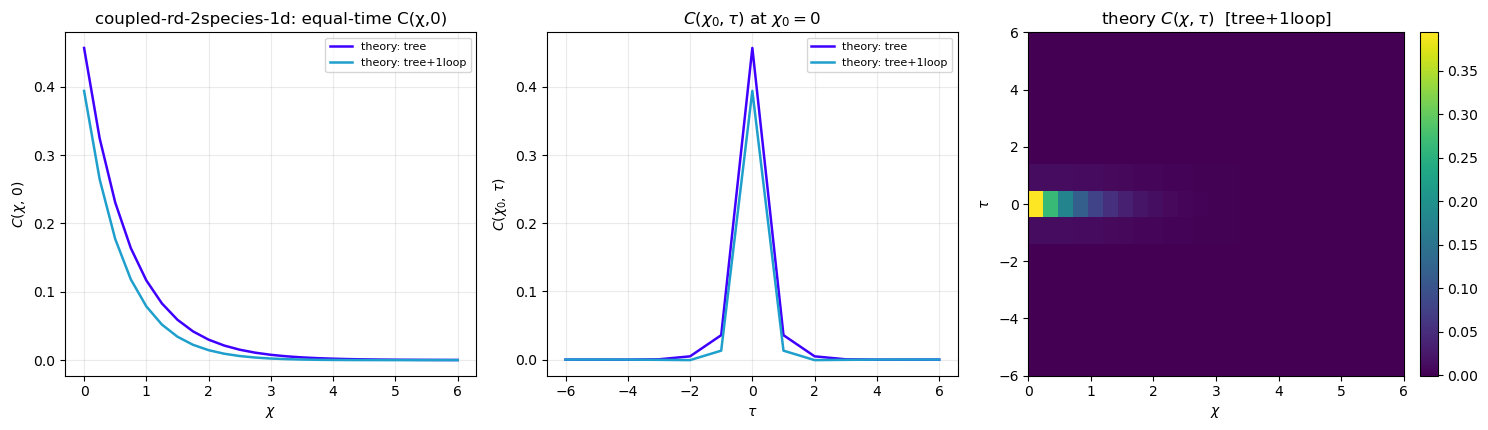

In [4]:
res = dd.run(model, cfg, mod)
print(dd.summary(res))
dd.plot_cumulant(res, cfg, model)   # theory only
plt.show()

## 3. Independent simulation

A direct integration of the coupled SPDE (semi-implicit Euler–Maruyama on a periodic ring) — no reference to the diagrammatics. The reaction and noise matrices are built from the **same theory parameters**, so overlaying field $a$'s auto-correlator $C_{aa}(\chi,\tau)$ on the theory — equal-time slice, temporal slices, and a matching $C(\chi,\tau)$ heatmap on a shared colour scale — is the validation.

theory C_aa(0,0) = 0.3941   sim C_aa(0,0) = 0.4062


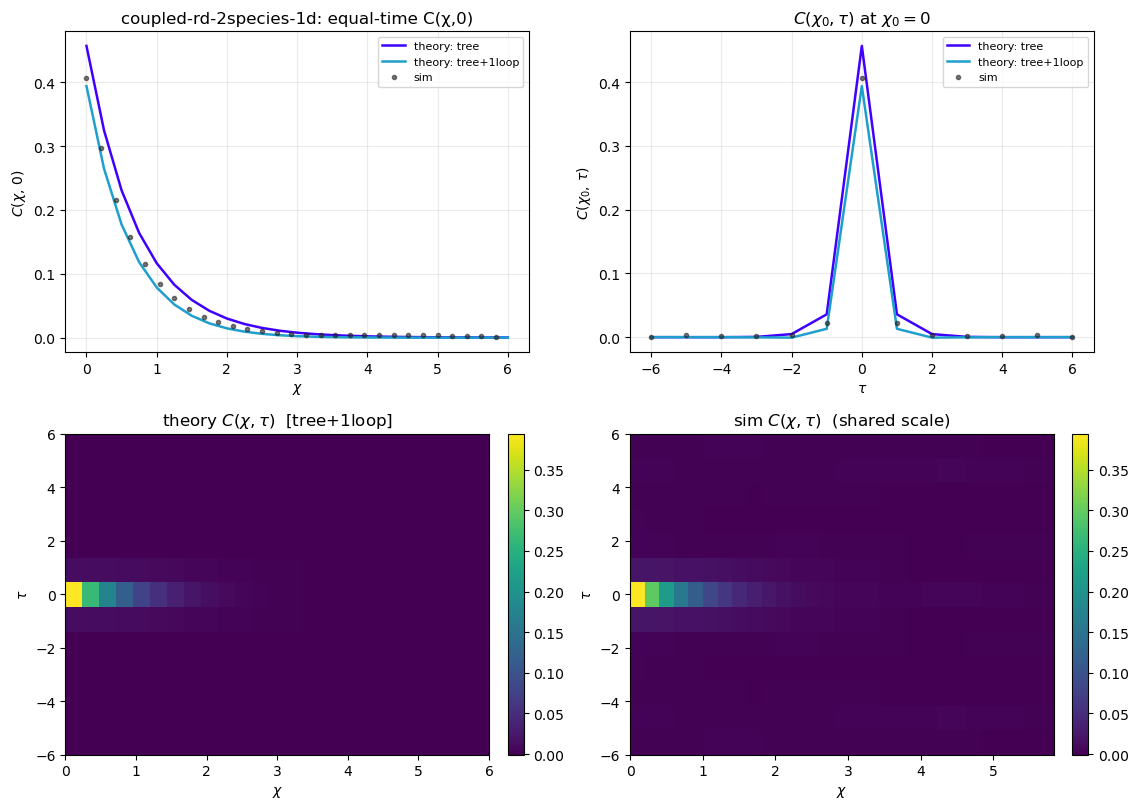

In [5]:
# Independent coupled-SPDE simulation (Euler–Maruyama, periodic ring) — NOT the pipeline.
# Field a's auto-correlator C_aa(χ,τ) (the coupled sim's [0,0] block) to overlay on theory.
from models.coupled_rd_1d_sim import simulate_coupled_rd_1d
fp = dd.parameters_from_model(model)
Mmat   = np.array([[fp['mua'], fp['g']], [-fp['h'], fp['mub']]])   # +g in a-eqn, −h in b-eqn
Nnoise = np.diag([2 * fp['Ta'], 2 * fp['Tb']])
pos = [float(t) for t in np.asarray(res['tau_grid']) if t >= 0]    # τ≥0 (sim mirrors τ<0)
raw = simulate_coupled_rd_1d(Mmat, float(fp['Da']), Nnoise,
                             g=(float(fp['ga']), float(fp['gb'])),
                             L=20.0, n_x=int(96), dt=2e-3, t_burn=25.0, t_run=300.0,
                             n_rep=int(4), seed=int(2), lags=tuple(pos))
taus = np.asarray(raw['taus']); xg = np.asarray(raw['x_grid'])
half = len(xg) // 2 + 1                                            # χ ≥ 0 half of the ring
chi_max = float(np.asarray(res['spatial_grid']).max())
mask = xg[:half] <= chi_max                                       # clip to the theory's χ range
Caa = np.real(raw['C'][:, 0, 0, :half])[:, mask]                  # C_aa(χ, τ≥0)
tau_full = np.concatenate([-taus[:0:-1], taus])                   # mirror: C_aa even in τ
Caa_full = np.concatenate([Caa[:0:-1], Caa], axis=0)
sim = {'x': xg[:half][mask], 'tau': tau_full, 'C': Caa_full}
mid = int(np.argmin(np.abs(res['tau_grid'])))
print('theory C_aa(0,0) = %.4f   sim C_aa(0,0) = %.4f'
      % (np.real(res['C_tau_x'])[mid][0], sim['C'][int(np.argmin(np.abs(tau_full)))][0]))
dd.plot_cumulant(res, cfg, model, sim=sim)   # 4 panels, same as the single-field examples
plt.show()

## Summary

The coupled tree (matrix Lyapunov correlator, analytic spectral IFT) and the 1-loop cubic-vertex correction both track the independent SPDE simulation for field $a$'s auto-correlator $C_{aa}(\chi,\tau)$. This is the spatial pipeline's **multi-field** mode — every coupled diagram reduced to a weighted sum of scalar chamber integrals — shown here on the same single-correlator footing as the single-field examples (swap `('da',…)` for `('db',…)` or a cross pair `[('da',1),('db',1)]` to probe the other components).